In [1]:
import sys
from pathlib import Path
import os 
import time
import glob
import itertools
import matplotlib.pyplot as plt
import pandas as pd
import random
PROJECT_ROOT = Path.cwd().parents[0]   # adjust if needed
sys.path.append(str(PROJECT_ROOT))
from src.jdr import jdr, jdr_parallel
from src.JDRKMedoids import JDRKMedoids
from src.JDRDBSCAN import JDRDBSCAN
from astropy.timeseries import LombScargle
import pandas as pd
import numpy as np



In [2]:
PROJECT_ROOT

PosixPath('/home/franciscoperez/Documents/GitHub/JDR-Python')

In [3]:

# Directory containing .dat files
data_dir = "../data"

# Find all .dat files
files = sorted(glob.glob(os.path.join(data_dir, "*RRLYR*.dat")))[:50]

print(f"Found {len(files)} files")

Found 50 files


In [4]:
#df_results = pd.DataFrame(results, columns=['file1', 'file2', 'jdr', 'time'])

In [5]:
# Build JDR distance matrix
D = JDRKMedoids.build_distance_matrix(
    files=files,
    distance_func=jdr_parallel,   # or jdrDeark
    verbose=True
)

Computed distances for pair (0, 20)
Computed distances for pair (0, 40)
Computed distances for pair (0, 49)
Computed distances for pair (1, 20)
Computed distances for pair (1, 40)
Computed distances for pair (1, 49)
Computed distances for pair (2, 20)
Computed distances for pair (2, 40)
Computed distances for pair (2, 49)
Computed distances for pair (3, 20)
Computed distances for pair (3, 40)
Computed distances for pair (3, 49)
Computed distances for pair (4, 20)
Computed distances for pair (4, 40)
Computed distances for pair (4, 49)
Computed distances for pair (5, 20)
Computed distances for pair (5, 40)
Computed distances for pair (5, 49)
Computed distances for pair (6, 20)
Computed distances for pair (6, 40)
Computed distances for pair (6, 49)
Computed distances for pair (7, 20)
Computed distances for pair (7, 40)
Computed distances for pair (7, 49)
Computed distances for pair (8, 20)
Computed distances for pair (8, 40)
Computed distances for pair (8, 49)
Computed distances for pair 

In [6]:
# Fit clustering
 model = JDRKMedoids(
    n_clusters=5,
    max_iter=100,
    random_state=42,
    verbose=True
)
labels = model.fit_predict(D)

In [8]:

print("Medoid indices:", model.medoids_)
print("Medoid files:", model.get_medoid_files(files))
print("Clusters:", model.clusters_)
print("Inertia:", model.inertia_)

Medoid indices: [27, 7, 11, 47, 17]
Medoid files: ['../data/OGLE-BLG-RRLYR-00028.dat', '../data/OGLE-BLG-RRLYR-00008.dat', '../data/OGLE-BLG-RRLYR-00012.dat', '../data/OGLE-BLG-RRLYR-00048.dat', '../data/OGLE-BLG-RRLYR-00018.dat']
Clusters: [[0, 2, 9, 19, 23, 27, 32, 33, 34, 35, 36, 39, 40, 41, 44, 46], [7, 8, 31, 45], [1, 4, 5, 6, 10, 11, 12, 13, 15, 18, 20, 24, 25, 28, 29, 42, 43, 48], [3, 16, 21, 22, 26, 30, 47, 49], [14, 17, 37, 38]]
Inertia: 0.2599149648561982


In [9]:
cols = ["id", "field", "star_id", "type", "ra", "dec"]

df = pd.read_csv(
    "ident.dat",
    sep=r"\s+",
    header=None,
    usecols=[0, 1, 2, 3, 4, 5],
    names=cols,
    engine="python"
)

df[['id', 'type']].head()

,id,type
0,OGLE-BLG-RRLYR-00001,RRab
1,OGLE-BLG-RRLYR-00002,RRc
2,OGLE-BLG-RRLYR-00003,RRab
3,OGLE-BLG-RRLYR-00004,RRab
4,OGLE-BLG-RRLYR-00005,RRab


In [10]:
model.get_medoid_files(files)

['../data/OGLE-BLG-RRLYR-00028.dat',
 '../data/OGLE-BLG-RRLYR-00008.dat',
 '../data/OGLE-BLG-RRLYR-00012.dat',
 '../data/OGLE-BLG-RRLYR-00048.dat',
 '../data/OGLE-BLG-RRLYR-00018.dat']

In [11]:
file_to_subclass = {}
medoid_files = model.get_medoid_files(files)
for f in medoid_files:
    obj_id = os.path.splitext(os.path.basename(f))[0]   # remove path and .dat
    file_to_subclass[obj_id] = df[df.id==obj_id]['type'].values[0]

print(file_to_subclass)

{'OGLE-BLG-RRLYR-00028': 'RRc', 'OGLE-BLG-RRLYR-00008': 'RRab', 'OGLE-BLG-RRLYR-00012': 'RRc', 'OGLE-BLG-RRLYR-00048': 'RRc', 'OGLE-BLG-RRLYR-00018': 'RRc'}


In [12]:
cluster_files = model.get_cluster_files(files)

objects_by_class = {}

print("\nFiles in each cluster:")
for k, cluster in enumerate(cluster_files):
    print(f"Cluster {k}:")
    objects = []
    for f in cluster:
        print("  ", f)
        objects.append(os.path.splitext(os.path.basename(f))[0])
    objects_by_class[str(k)] = objects


Files in each cluster:
Cluster 0:
   ../data/OGLE-BLG-RRLYR-00001.dat
   ../data/OGLE-BLG-RRLYR-00003.dat
   ../data/OGLE-BLG-RRLYR-00010.dat
   ../data/OGLE-BLG-RRLYR-00020.dat
   ../data/OGLE-BLG-RRLYR-00024.dat
   ../data/OGLE-BLG-RRLYR-00028.dat
   ../data/OGLE-BLG-RRLYR-00033.dat
   ../data/OGLE-BLG-RRLYR-00034.dat
   ../data/OGLE-BLG-RRLYR-00035.dat
   ../data/OGLE-BLG-RRLYR-00036.dat
   ../data/OGLE-BLG-RRLYR-00037.dat
   ../data/OGLE-BLG-RRLYR-00040.dat
   ../data/OGLE-BLG-RRLYR-00041.dat
   ../data/OGLE-BLG-RRLYR-00042.dat
   ../data/OGLE-BLG-RRLYR-00045.dat
   ../data/OGLE-BLG-RRLYR-00047.dat
Cluster 1:
   ../data/OGLE-BLG-RRLYR-00008.dat
   ../data/OGLE-BLG-RRLYR-00009.dat
   ../data/OGLE-BLG-RRLYR-00032.dat
   ../data/OGLE-BLG-RRLYR-00046.dat
Cluster 2:
   ../data/OGLE-BLG-RRLYR-00002.dat
   ../data/OGLE-BLG-RRLYR-00005.dat
   ../data/OGLE-BLG-RRLYR-00006.dat
   ../data/OGLE-BLG-RRLYR-00007.dat
   ../data/OGLE-BLG-RRLYR-00011.dat
   ../data/OGLE-BLG-RRLYR-00012.dat
   ../d

In [13]:
for cluster in objects_by_class.keys(): 
    print('Cluster: ', cluster)
    for light_curve in objects_by_class[cluster]: 
        print(df[df.id== light_curve]['type'].values[0])

Cluster:  0
RRab
RRab
RRab
RRab
RRc
RRc
RRc
RRab
RRc
RRc
RRc
RRc
RRab
RRab
RRab
RRab
Cluster:  1
RRab
RRab
RRc
RRab
Cluster:  2
RRc
RRab
RRab
RRc
RRc
RRc
RRc
RRab
RRab
RRab
RRab
RRab
RRc
RRab
RRab
RRab
RRc
RRab
Cluster:  3
RRab
RRc
RRc
RRc
RRab
RRab
RRc
RRab
Cluster:  4
RRc
RRc
RRc
RRd


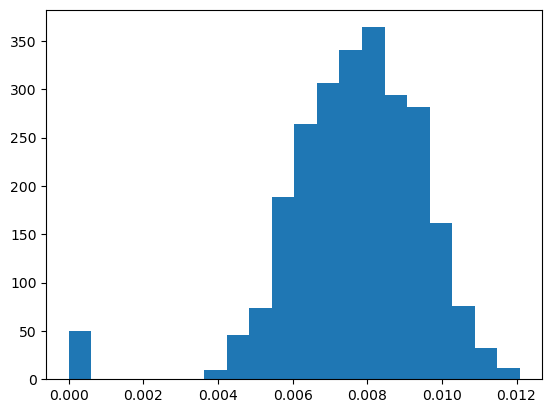

In [14]:
plt.hist(D.reshape(-1), bins=20)
plt.show()

In [15]:
files
labels = []
for light_curve in files: 
    labels.append(df[df.id==os.path.splitext(os.path.basename(light_curve))[0]]['type'].values[0])


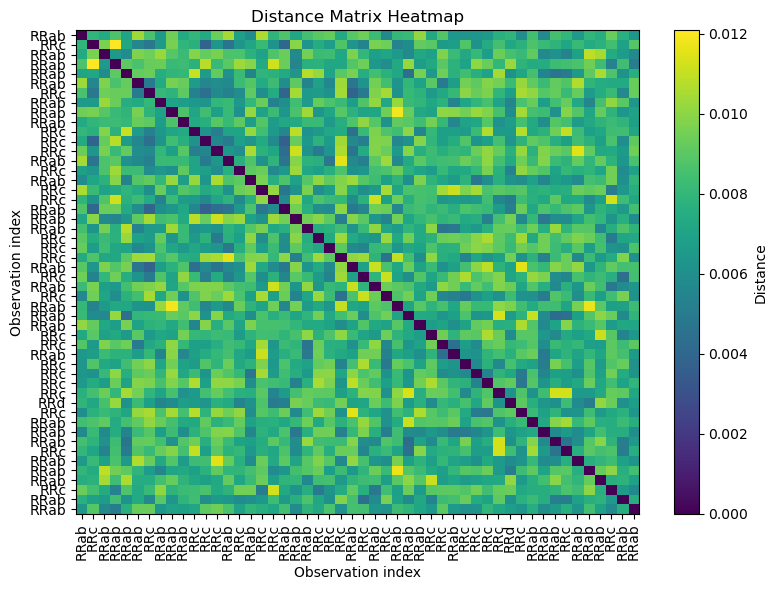

In [16]:
plt.figure(figsize=(8, 6))
im = plt.imshow(D, aspect="auto")
plt.colorbar(im, label="Distance")
plt.title("Distance Matrix Heatmap")
plt.xlabel("Observation index")
plt.ylabel("Observation index")

plt.xticks(ticks=range(len(labels)), labels=labels, rotation=90)
plt.yticks(ticks=range(len(labels)), labels=labels)

plt.tight_layout()
plt.show()

In [17]:
def estimate_period(dat_file, min_period=0.2, max_period=1.0):
    df = pd.read_csv(dat_file, sep=r"\s+", header=None, comment="#")
    t = df.iloc[:, 0].to_numpy()
    y = df.iloc[:, 1].to_numpy()

    freq = np.linspace(1/max_period, 1/min_period, 20000)
    power = LombScargle(t, y).power(freq)
    best_freq = freq[np.argmax(power)]
    return 1 / best_freq


def read_light_curve(filepath):
    df = pd.read_csv(filepath, sep=r"\s+", header=None)
    t = df.iloc[:, 0].to_numpy()
    mag = df.iloc[:, 1].to_numpy()
    err = df.iloc[:, 2].to_numpy() if df.shape[1] > 2 else None
    return t, mag, err


def fold_time(t, period, t0=None):
    if t0 is None:
        t0 = np.min(t)
    phase = ((t - t0) / period) % 1.0
    return phase


def plot_original_and_folded(filepath, period, star_name=None):
    t, mag, err = read_light_curve(filepath)
    phase = fold_time(t, period)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Original light curve
    if err is not None:
        axes[0].errorbar(t, mag, yerr=err, fmt='.', alpha=0.7)
    else:
        axes[0].plot(t, mag, '.', alpha=0.7)

    axes[0].set_title(f"Original: {star_name or filepath}")
    axes[0].set_xlabel("Time")
    axes[0].set_ylabel("Magnitude")
    axes[0].invert_yaxis()
    axes[0].grid(alpha=0.3)

    # Folded light curve
    if err is not None:
        axes[1].errorbar(phase, mag, yerr=err, fmt='.', alpha=0.7)
        axes[1].errorbar(phase + 1, mag, yerr=err, fmt='.', alpha=0.7)
    else:
        axes[1].plot(phase, mag, '.', alpha=0.7)
        axes[1].plot(phase + 1, mag, '.', alpha=0.7)

    axes[1].set_title(f"Folded: {star_name or filepath}\nP = {period:.6f}")
    axes[1].set_xlabel("Phase")
    axes[1].set_ylabel("Magnitude")
    axes[1].invert_yaxis()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


Cluster 0


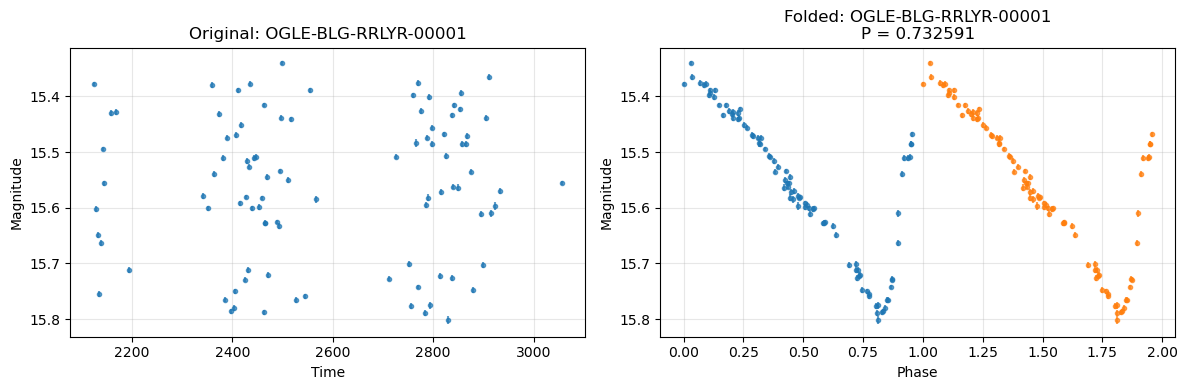

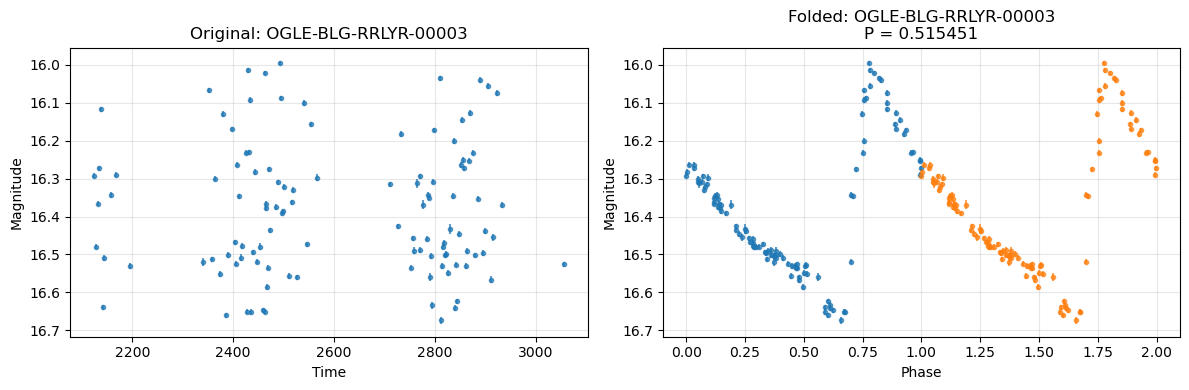

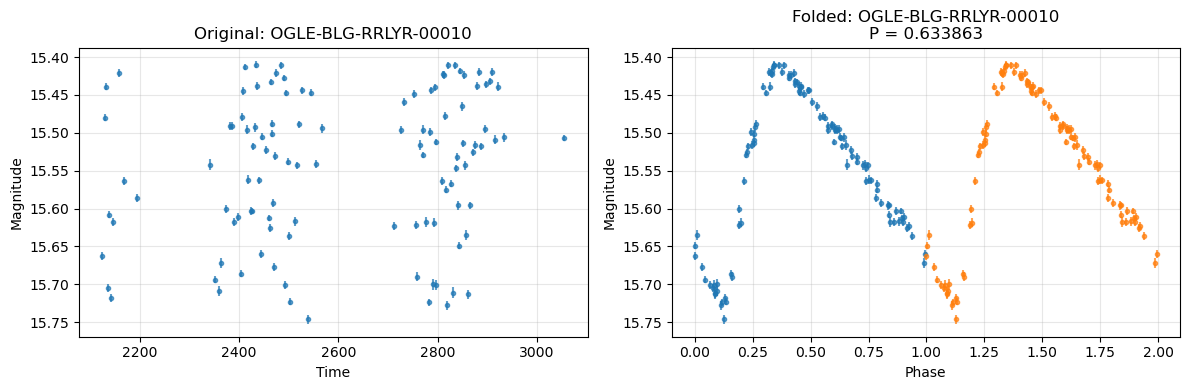

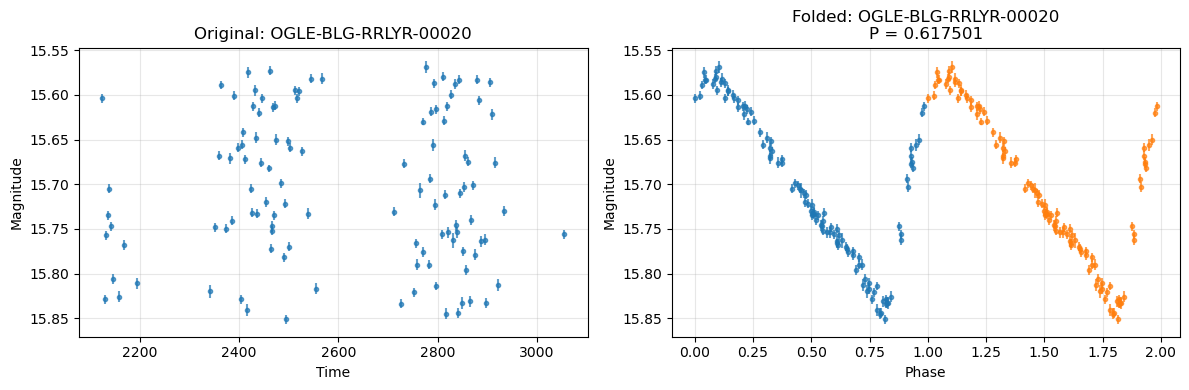

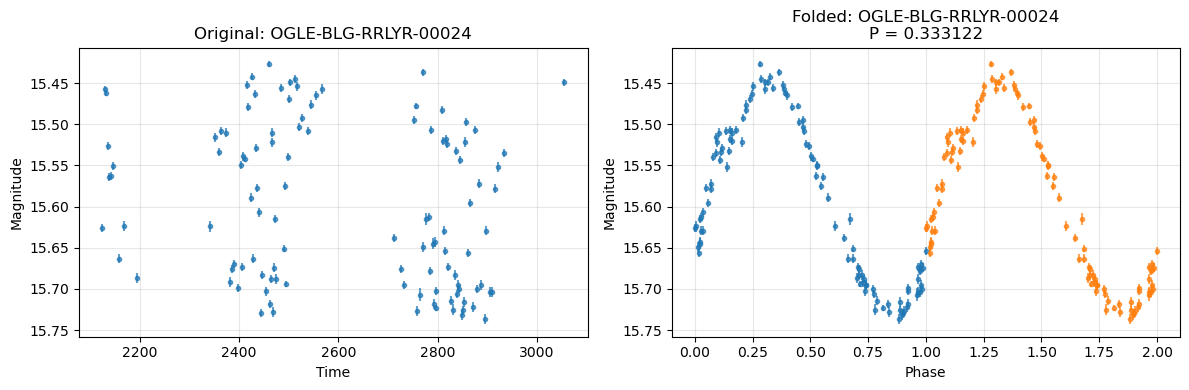

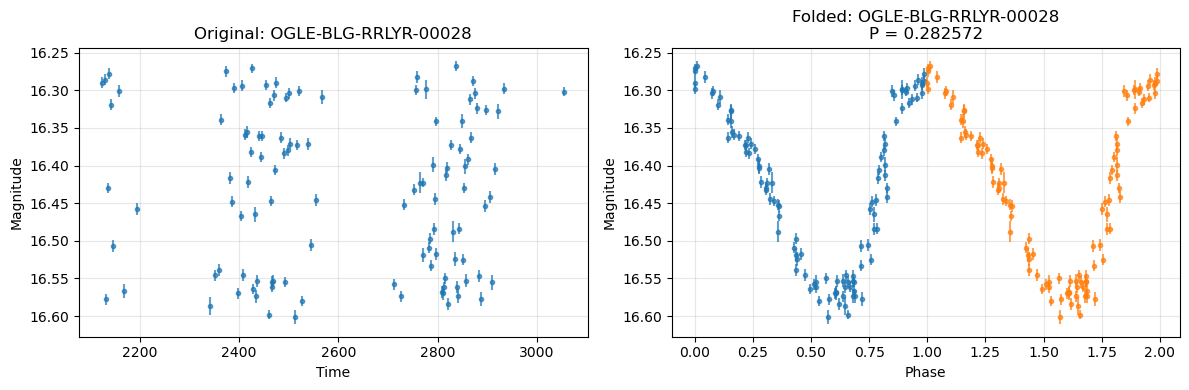

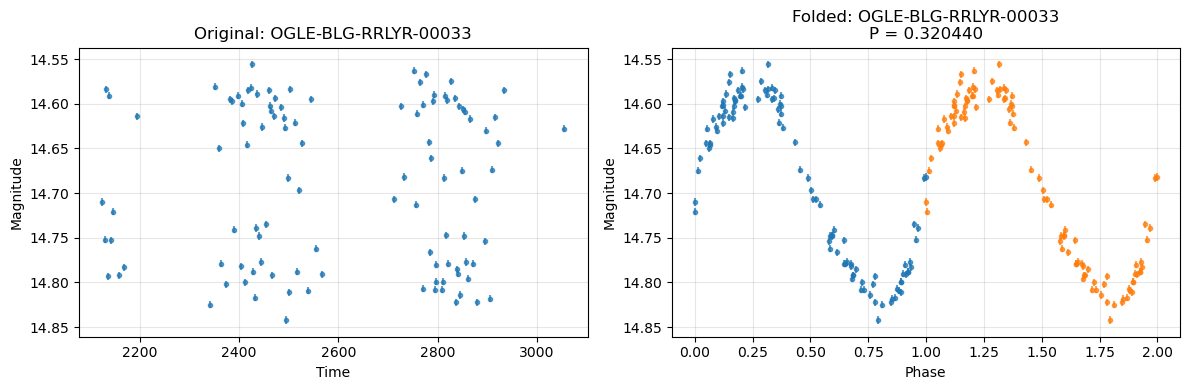

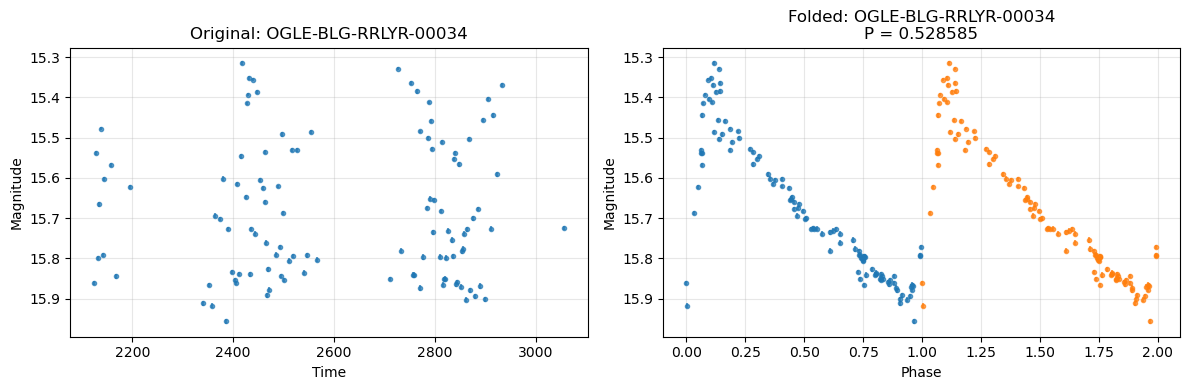

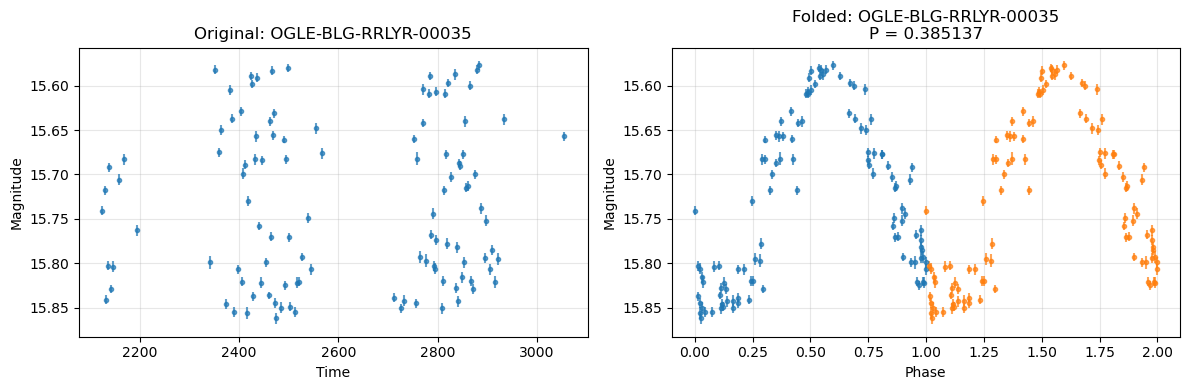

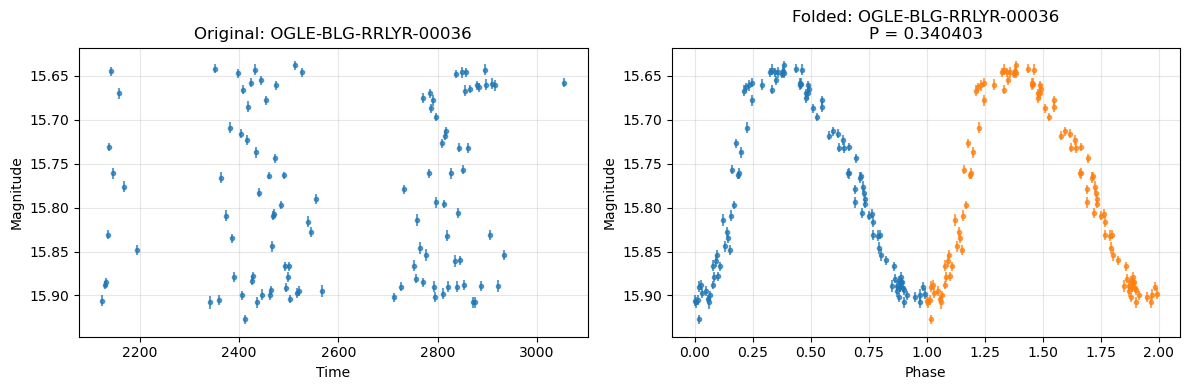

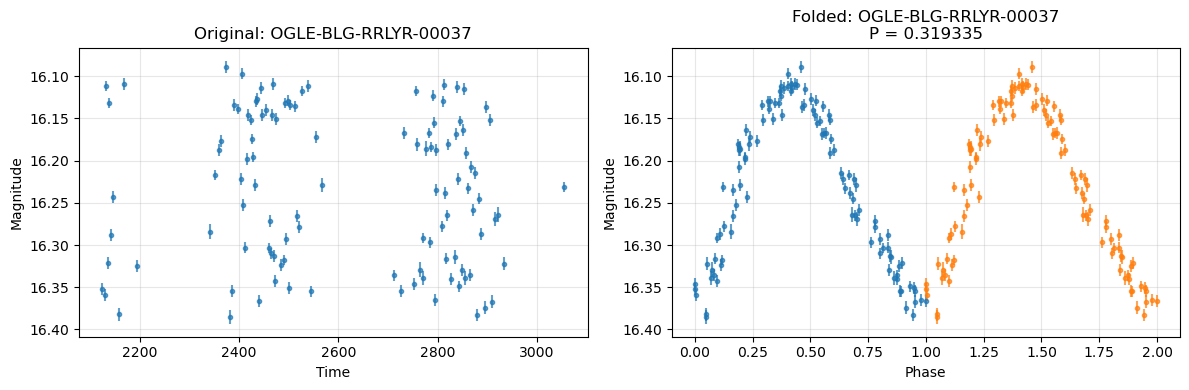

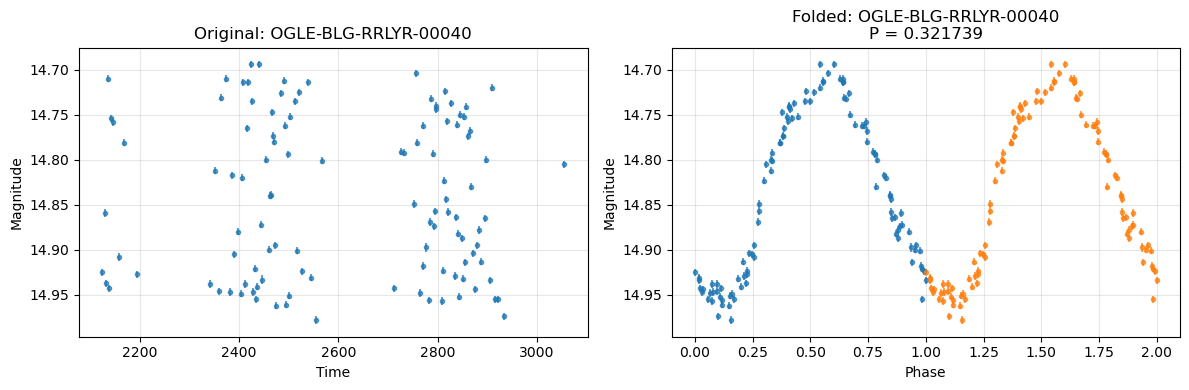

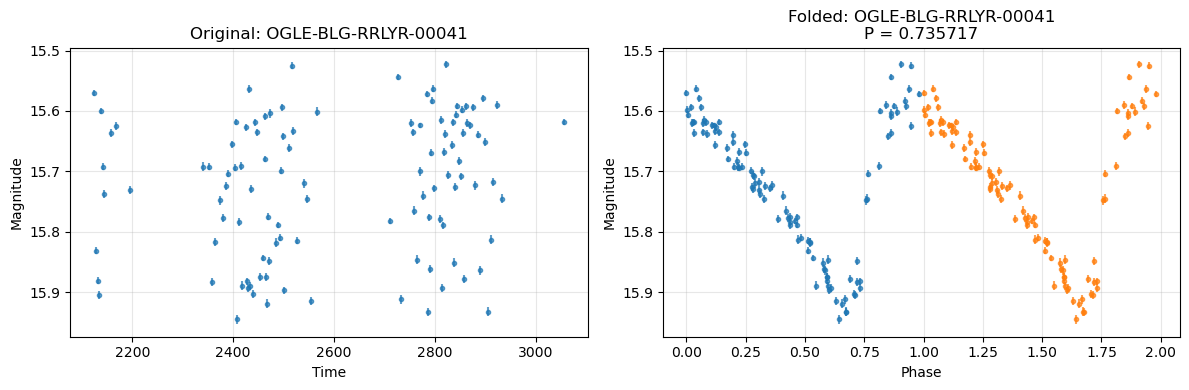

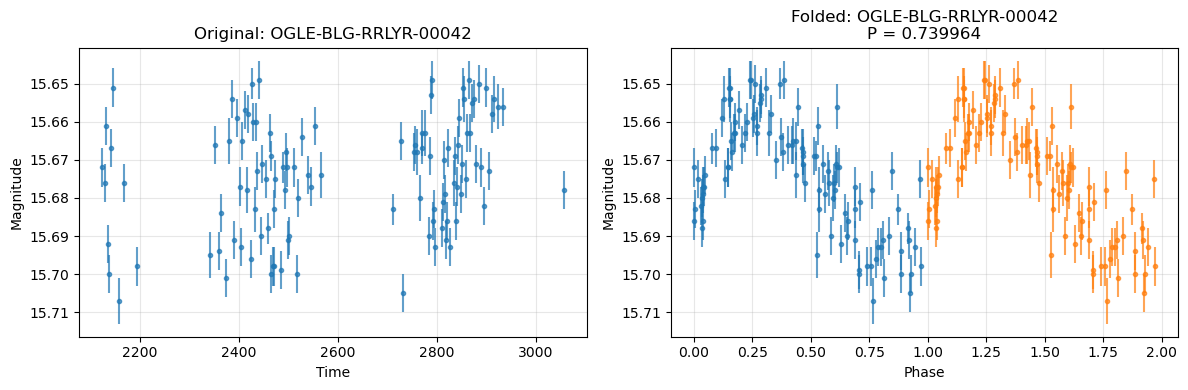

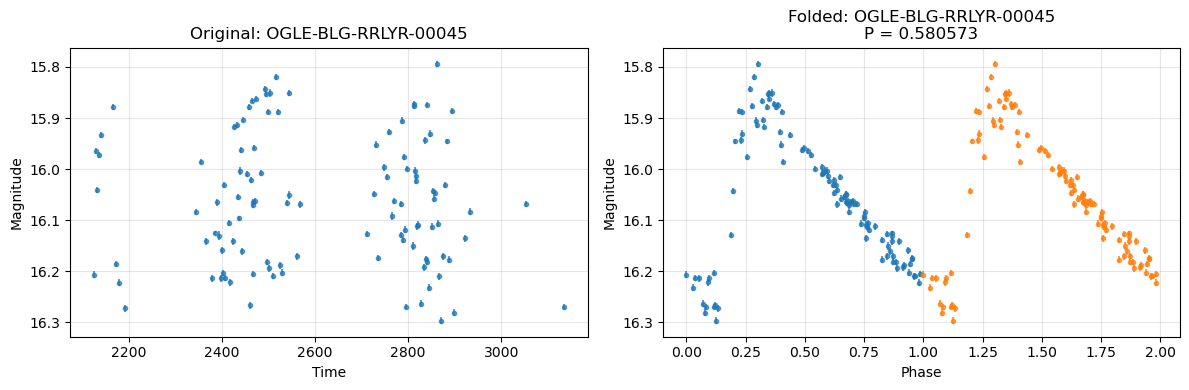

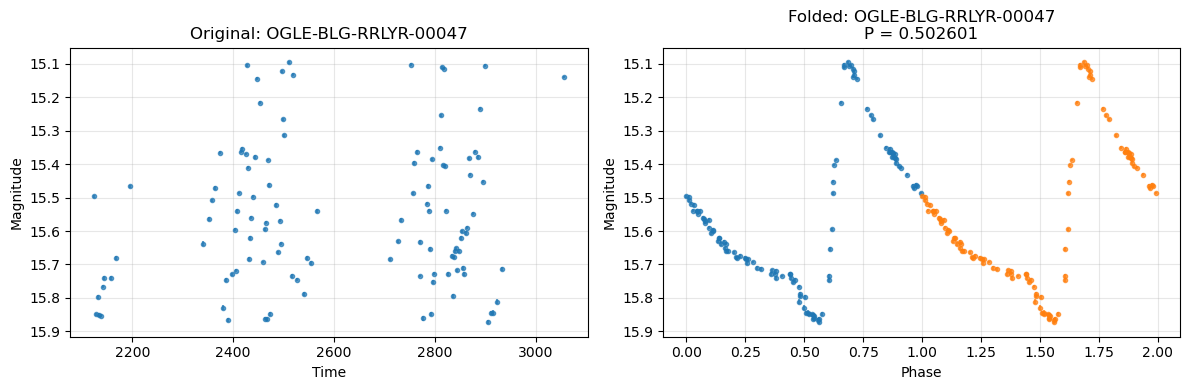


Cluster 1


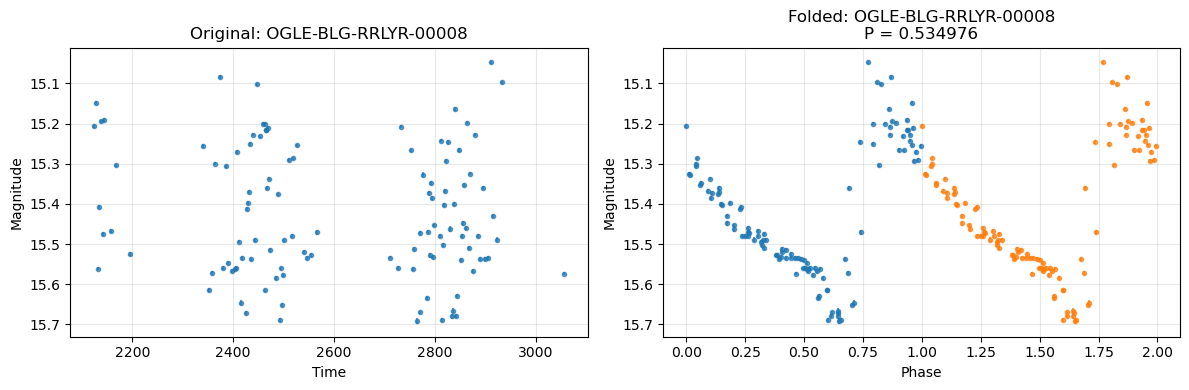

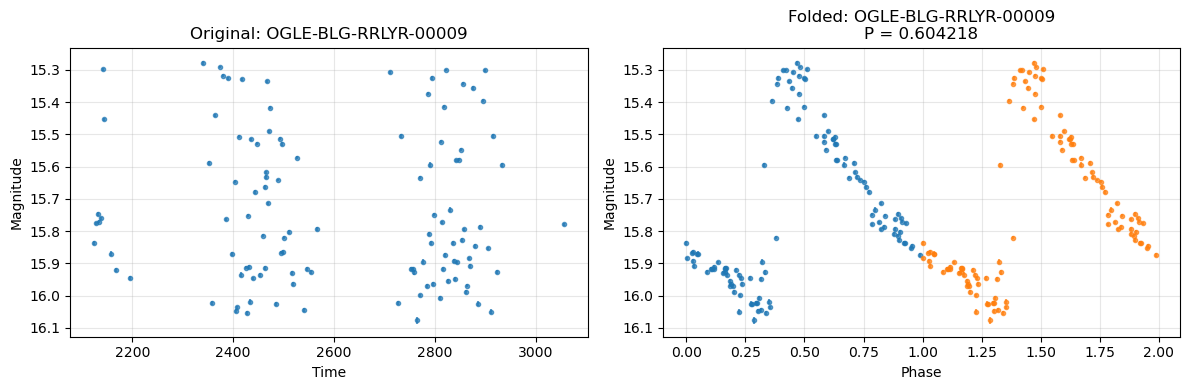

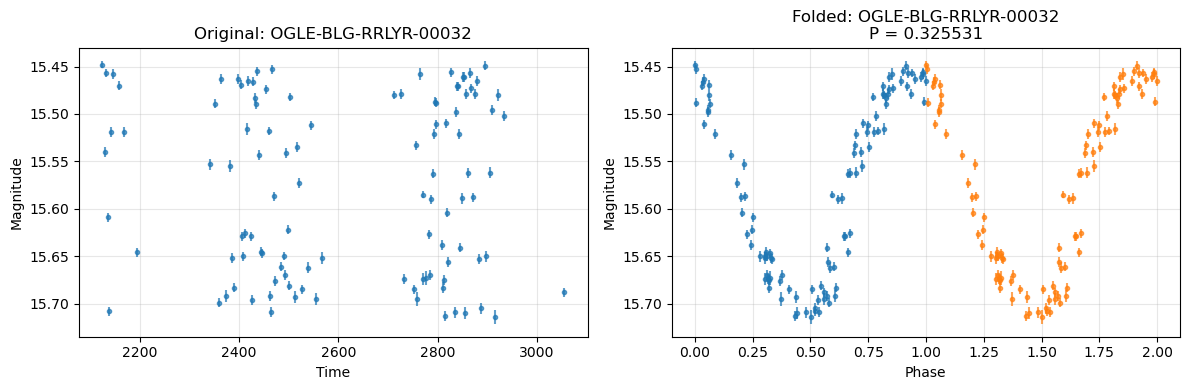

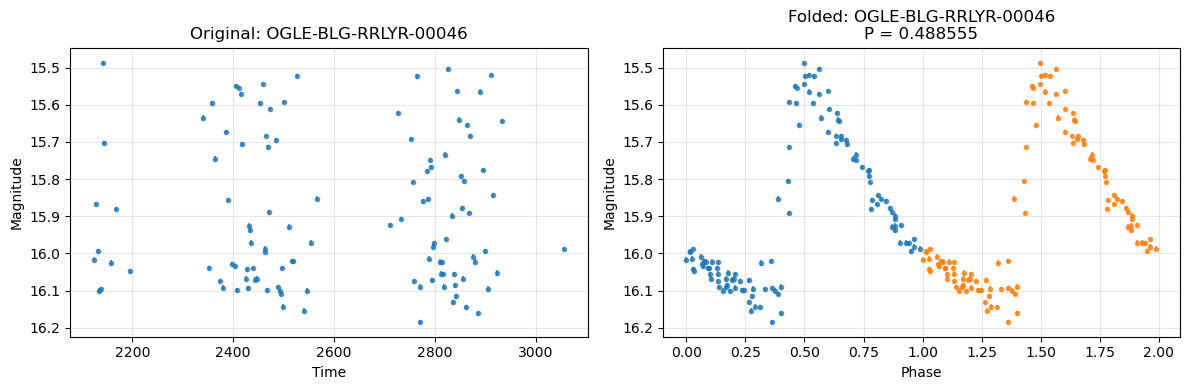


Cluster 2


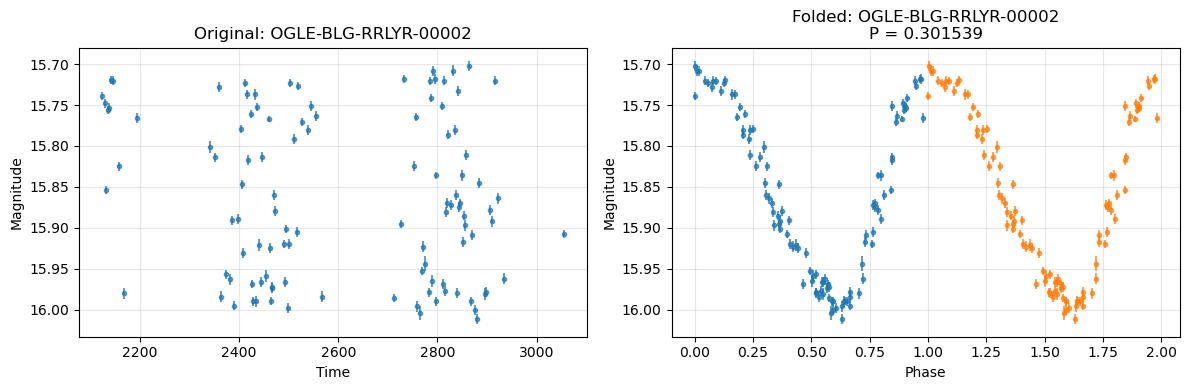

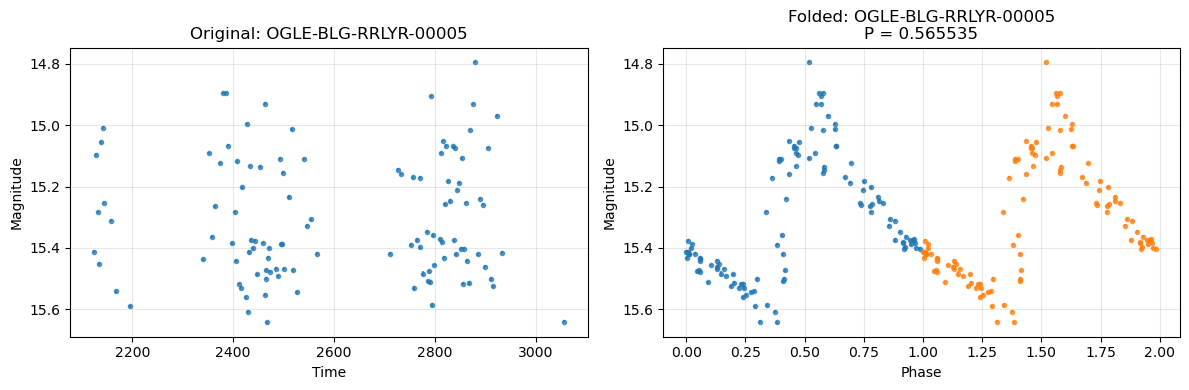

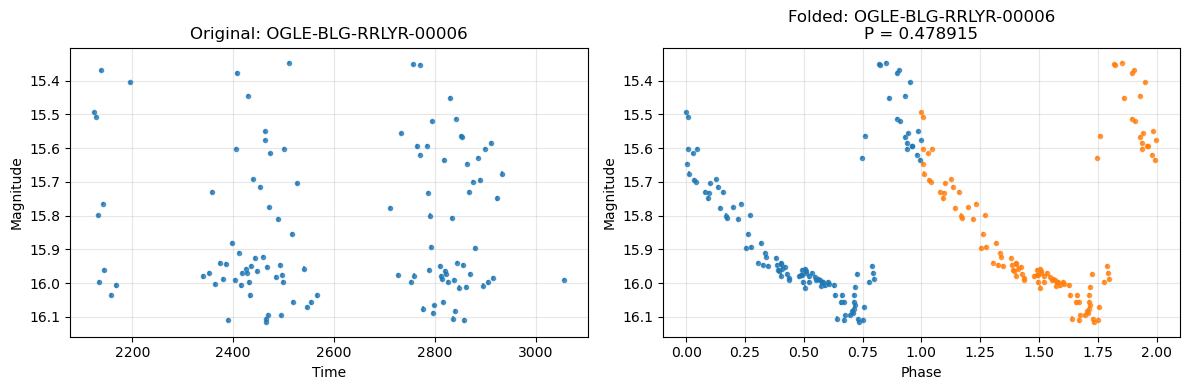

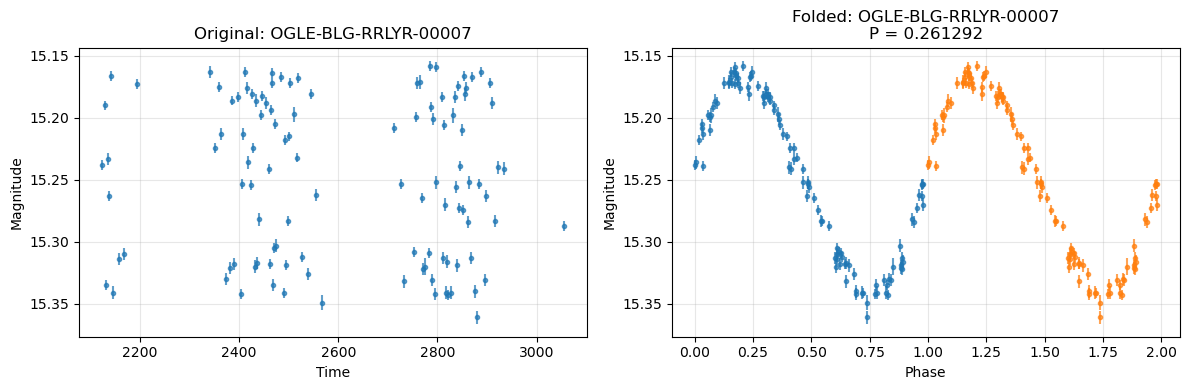

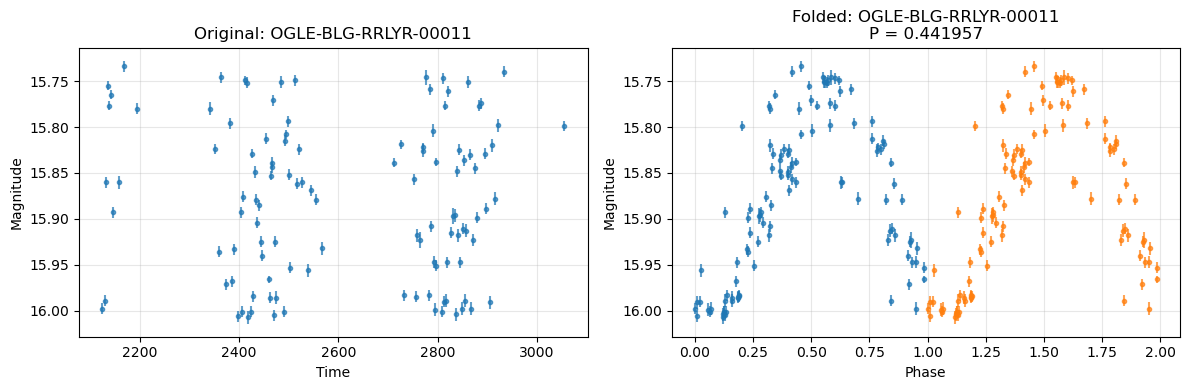

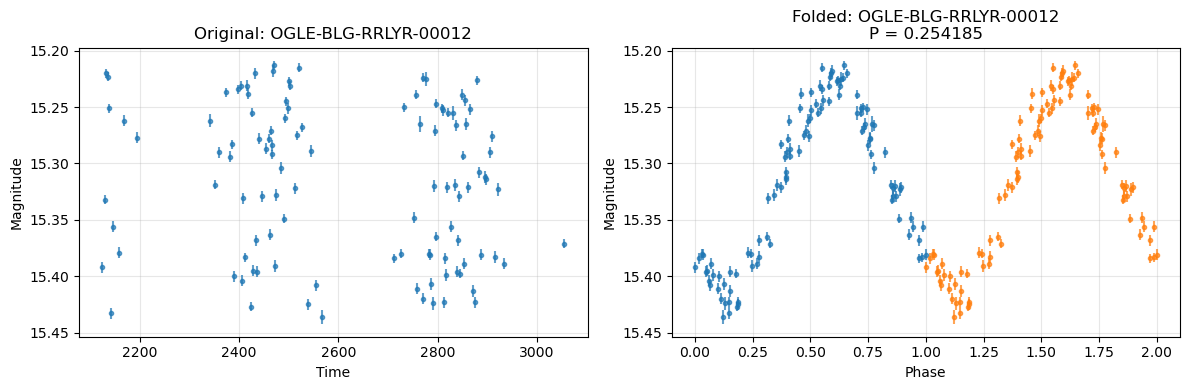

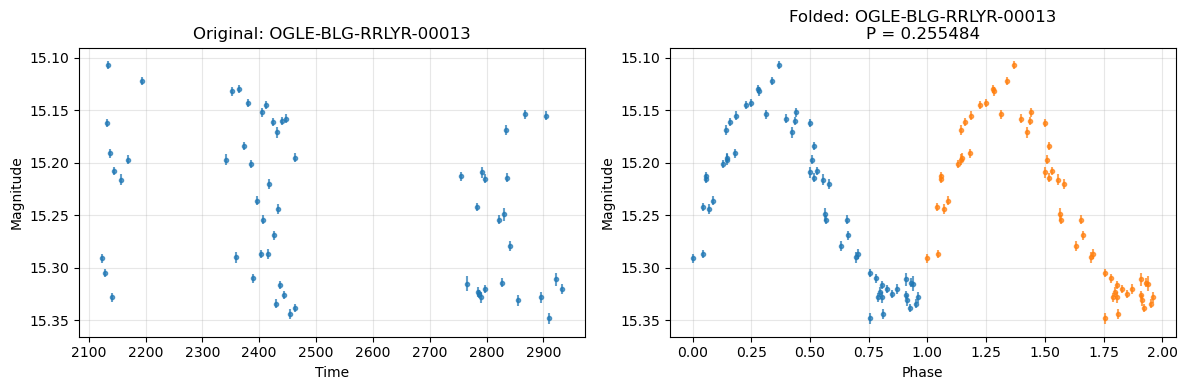

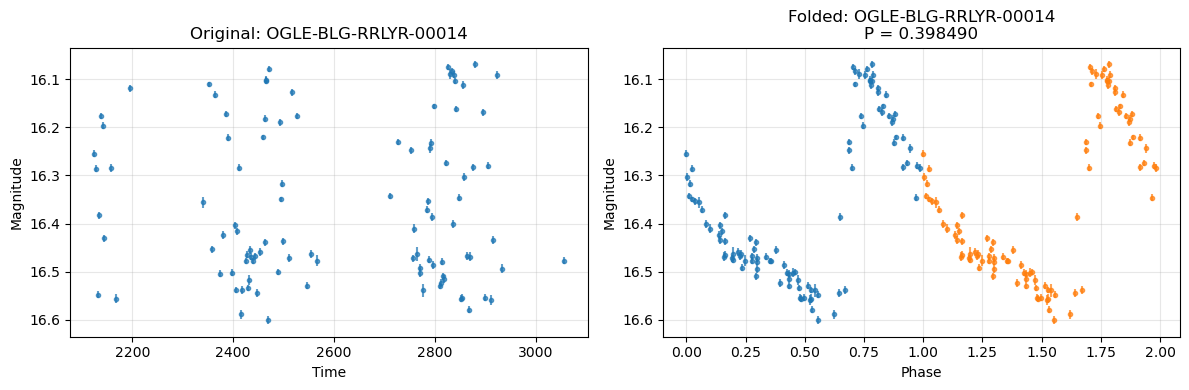

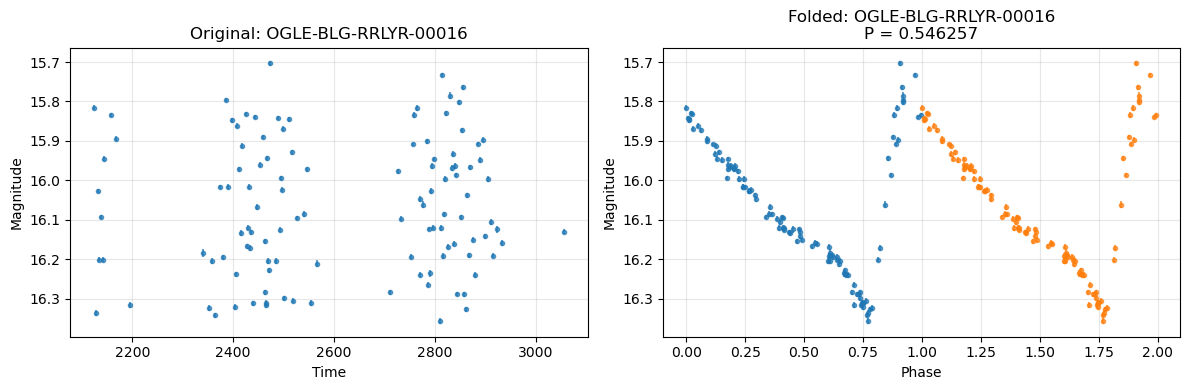

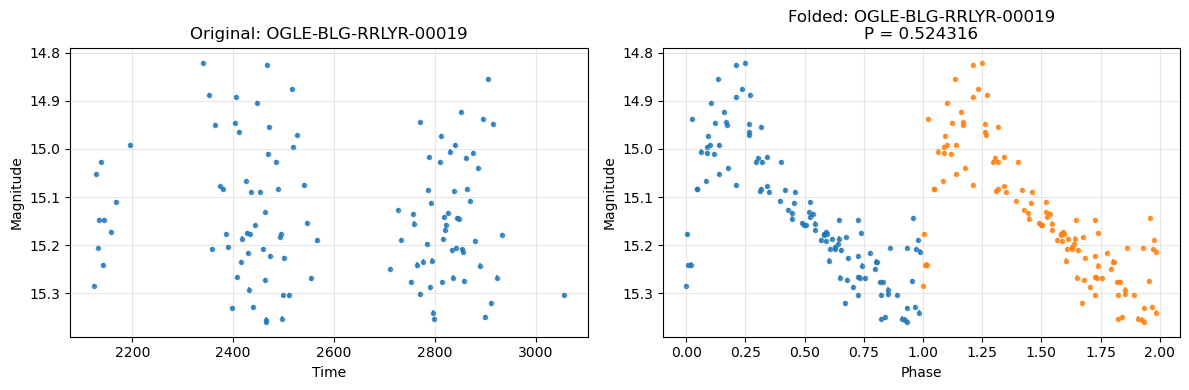

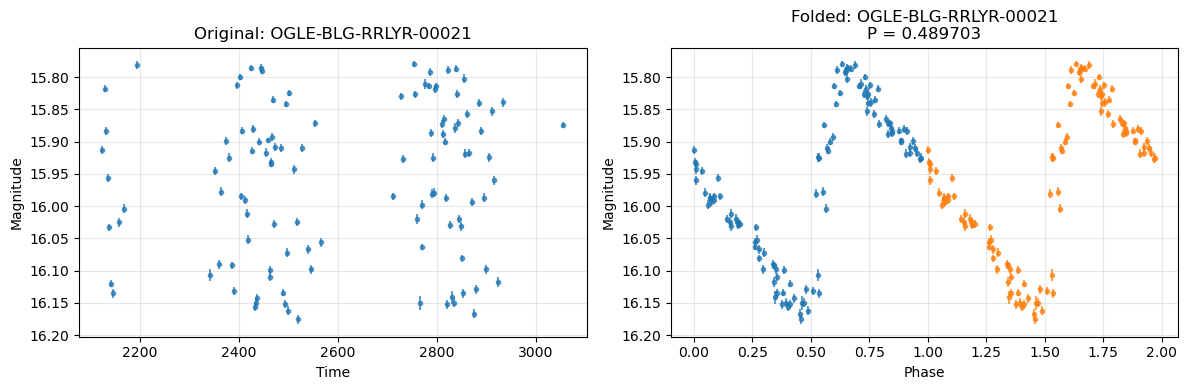

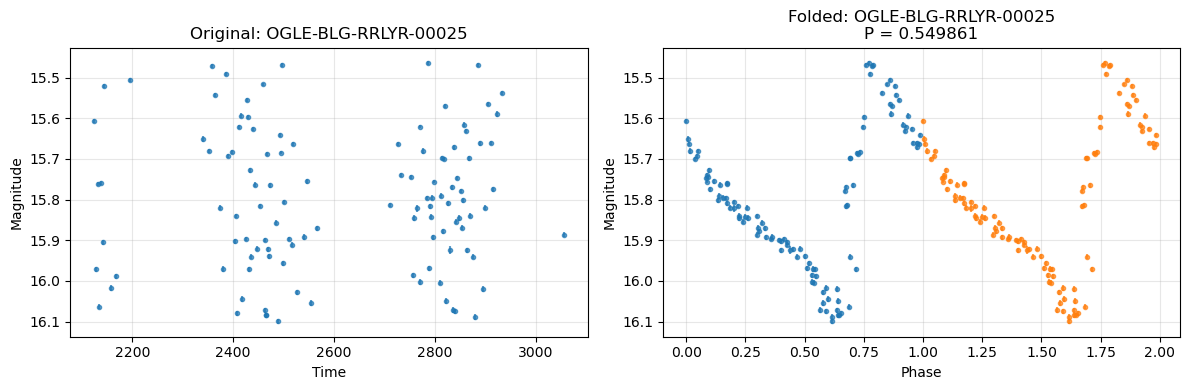

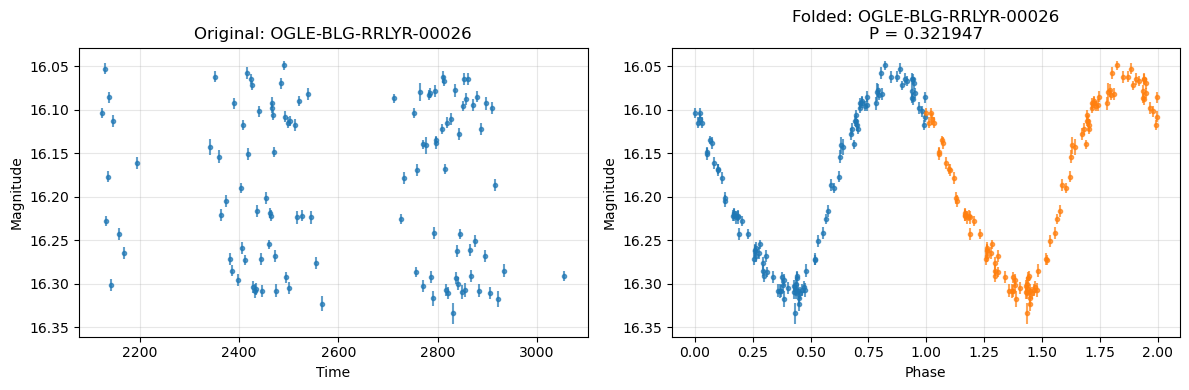

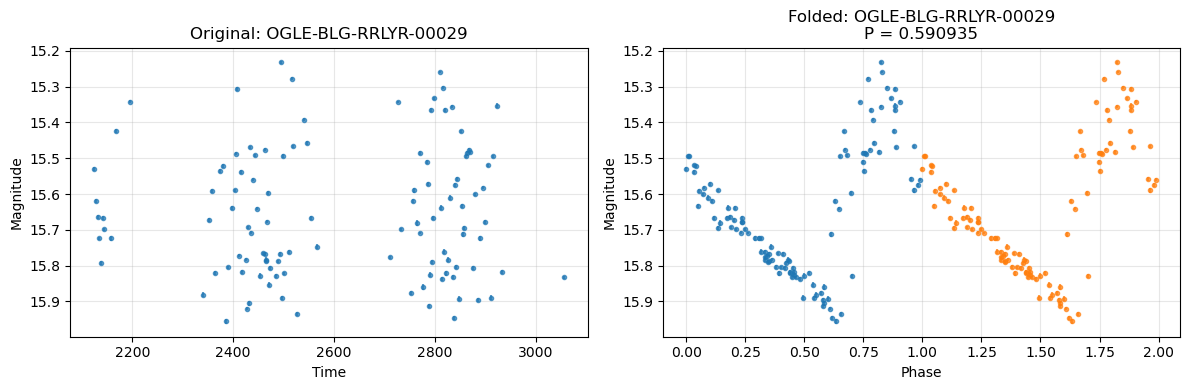

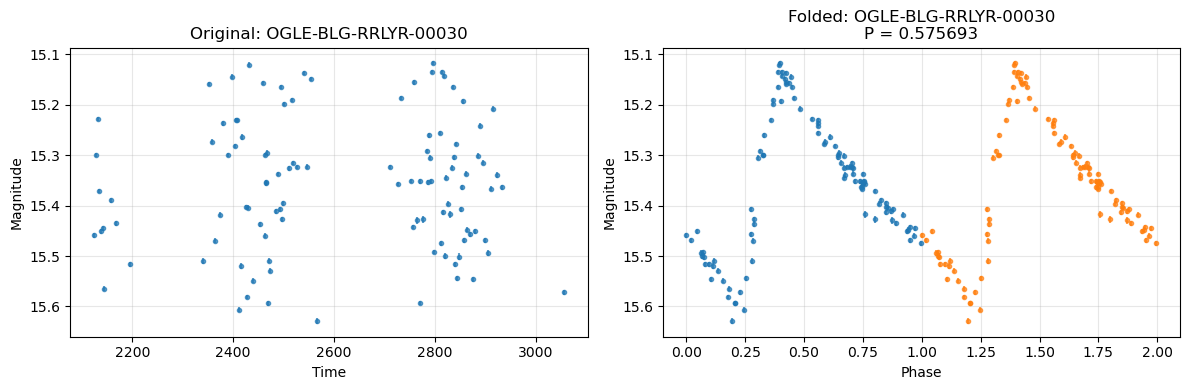

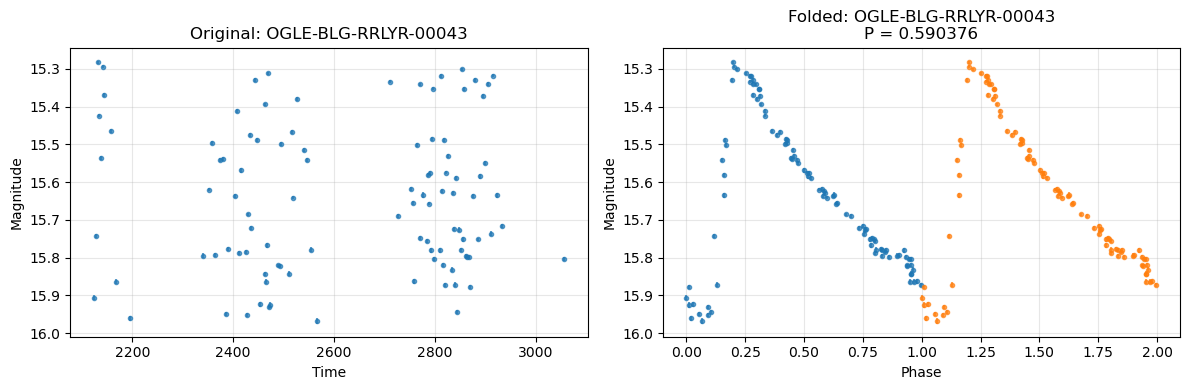

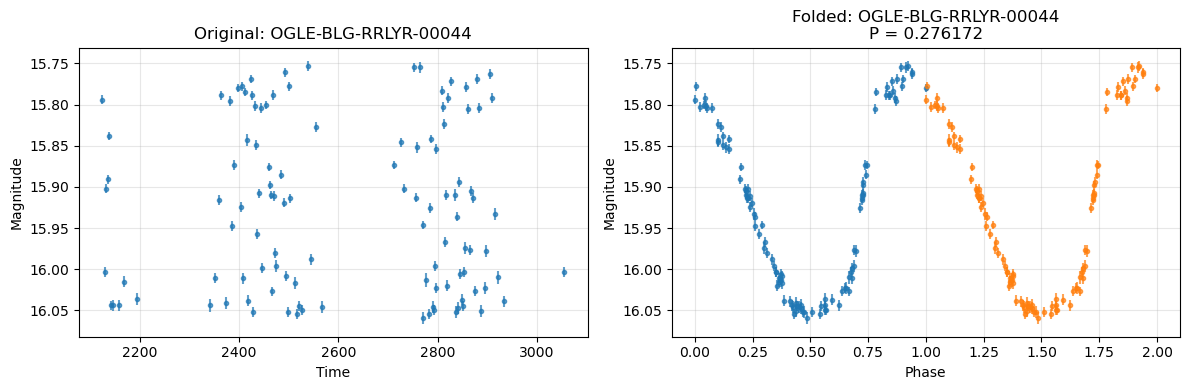

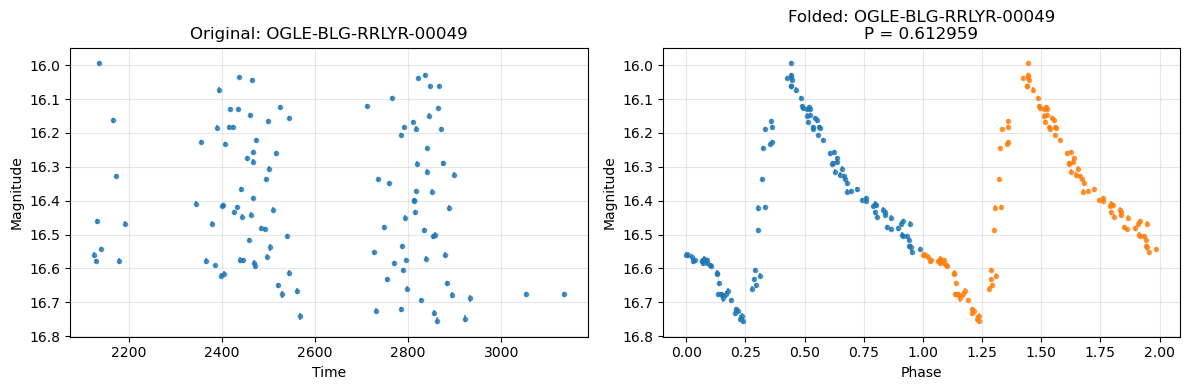


Cluster 3


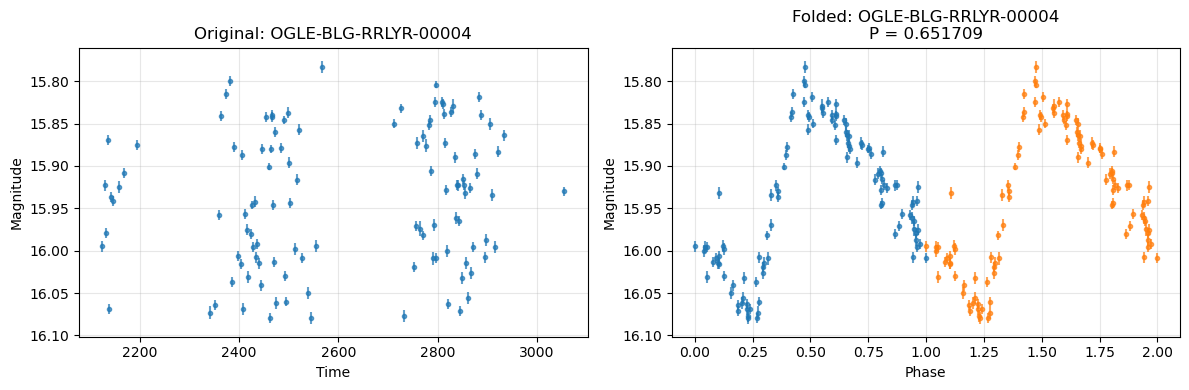

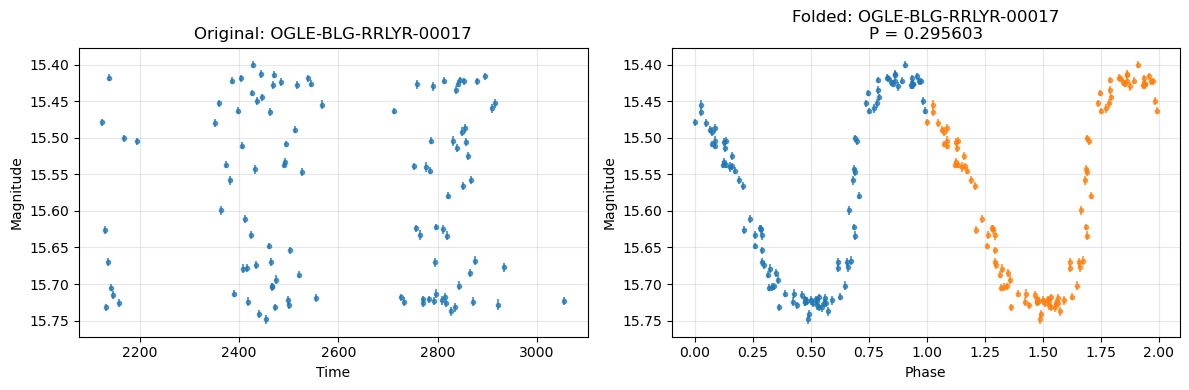

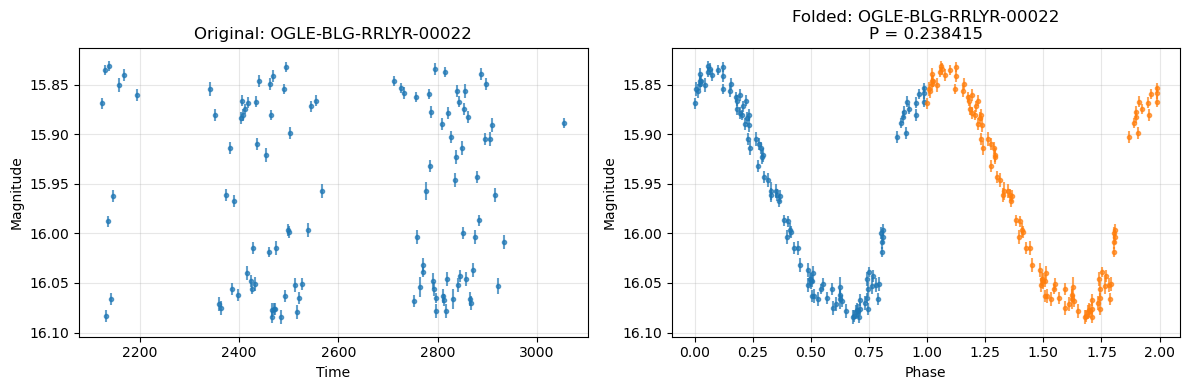

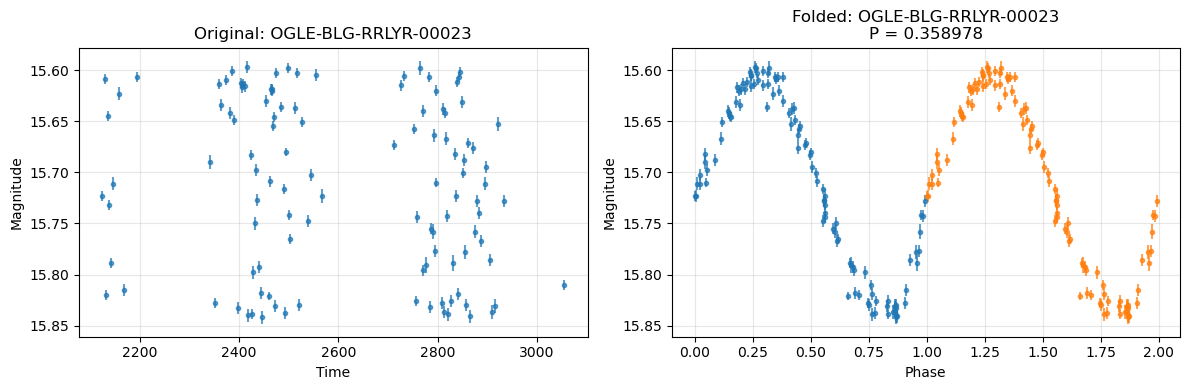

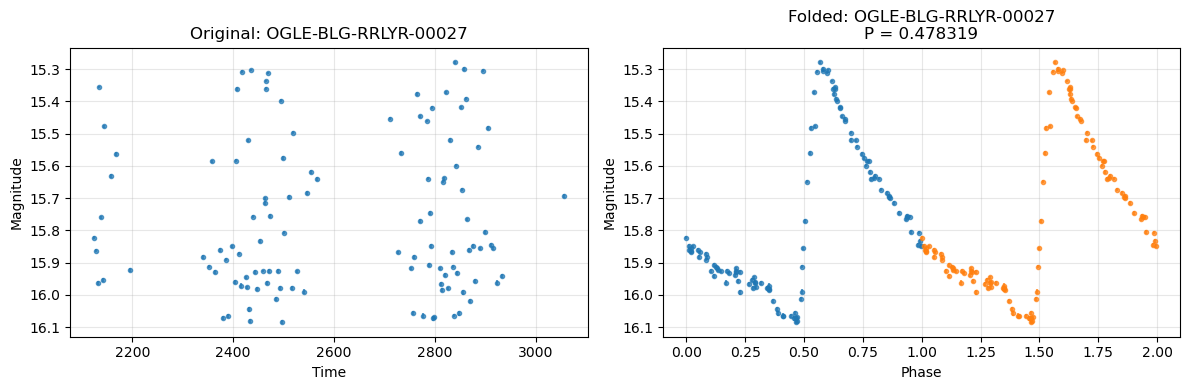

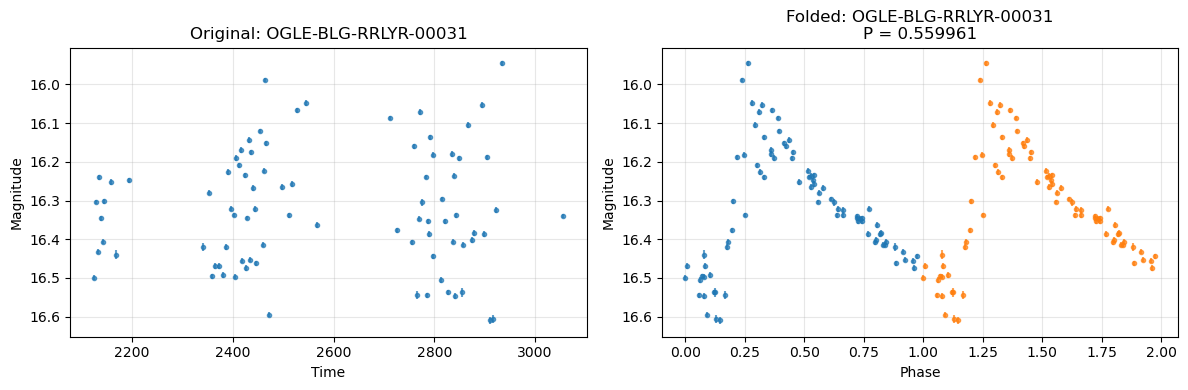

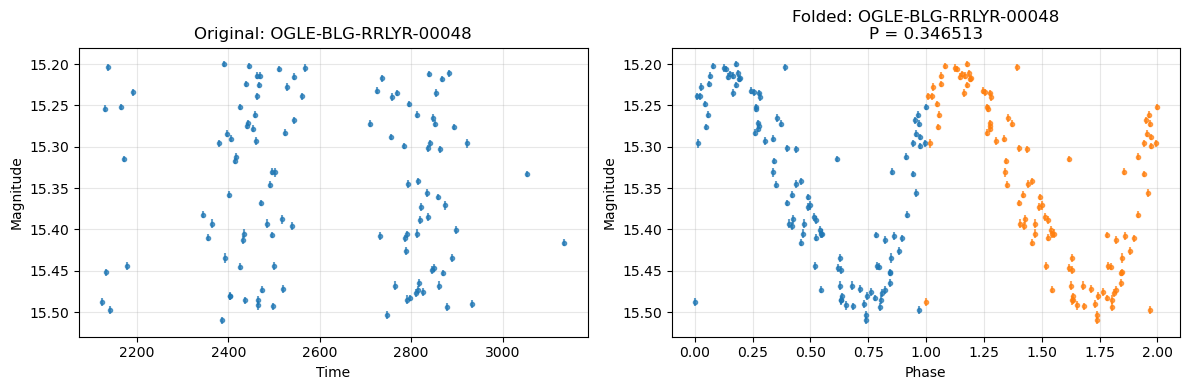

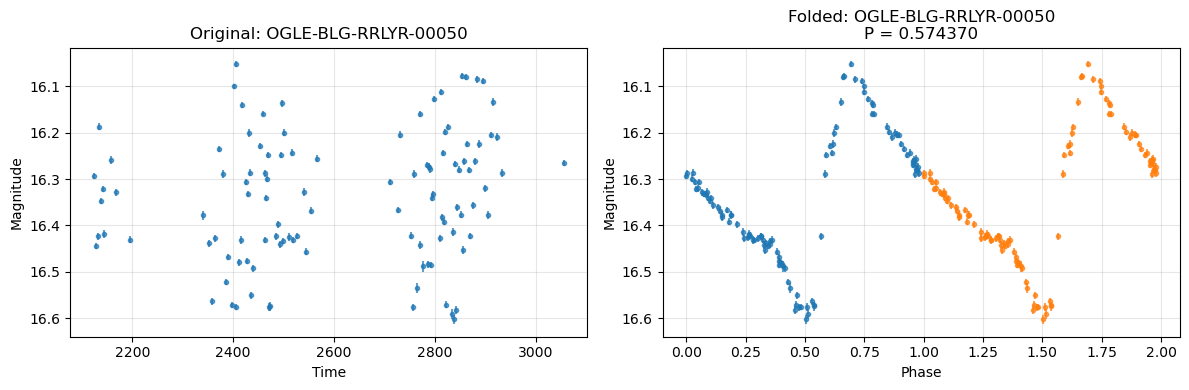


Cluster 4


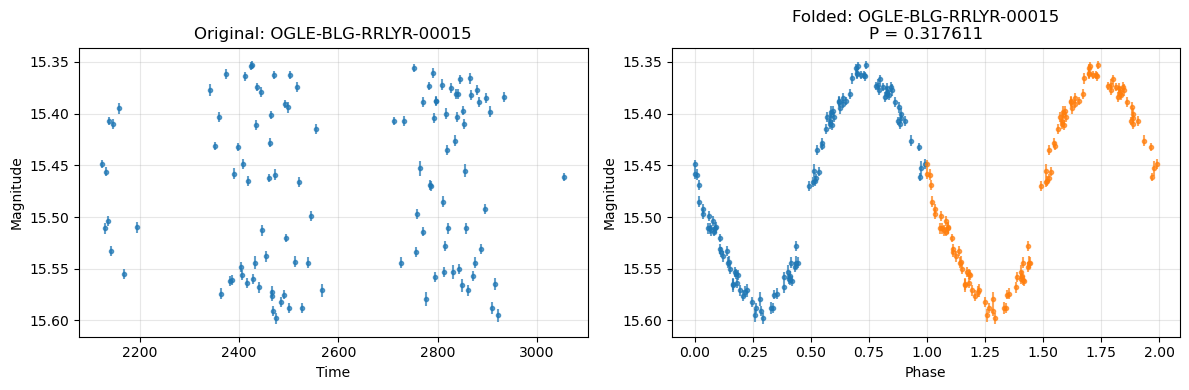

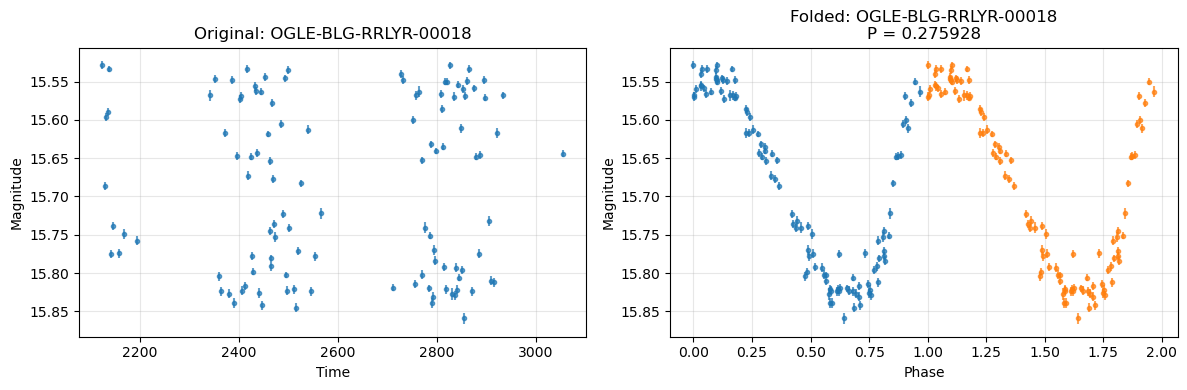

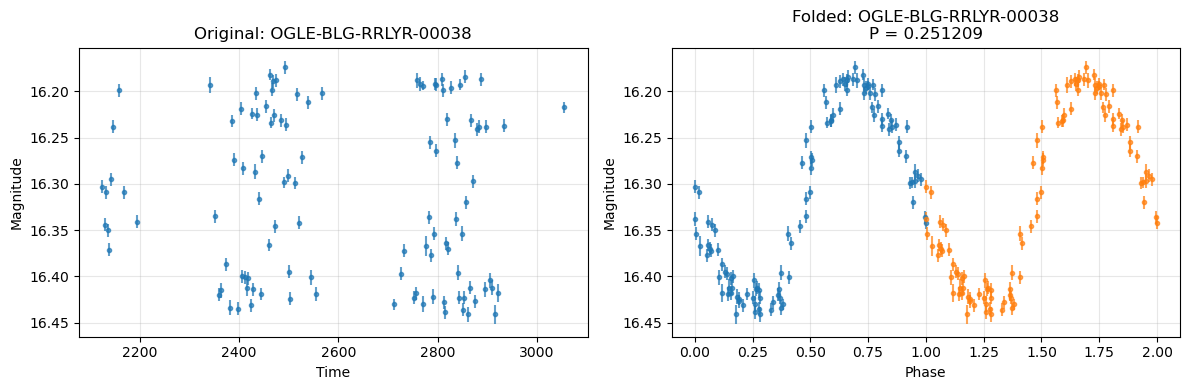

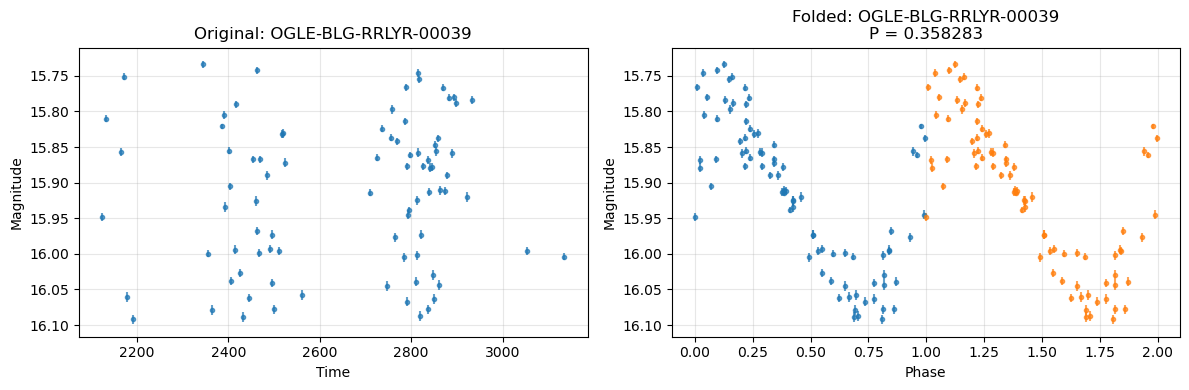

In [18]:
for cluster in objects_by_class.keys():
    print(f"\nCluster {cluster}")
    for star in objects_by_class[cluster]:
        filepath = f"../data/{star}.dat"
        period = estimate_period(filepath)
        plot_original_and_folded(filepath, period, star_name=star)
